<a href="https://colab.research.google.com/github/luladc/IA2/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
import numpy as np
import os
import timm

# 1. Configuración del dispositivo (usará GPU de Colab si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo configurado: {device}")

# 2. Crear el modelo con timm (EfficientNetV2 Small, ajustado a 19 clases)
# timm reemplaza automáticamente la capa final del clasificador por una de 19 salidas
modelo = timm.create_model('efficientnetv2_rw_s', pretrained=True, num_classes=19)
modelo = modelo.to(device)

# 3. Generar transformaciones automáticas y óptimas según la arquitectura
data_config = timm.data.resolve_model_data_config(modelo)
# Transformaciones de entrenamiento (incluyen Data Augmentation automático)
train_transforms = timm.data.create_transform(**data_config, is_training=True)
# Transformaciones de validación (solo redimensionamiento y recorte central)
val_transforms = timm.data.create_transform(**data_config, is_training=False)

print("¡Modelo y transformaciones configurados correctamente!")

Dispositivo configurado: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B / 96.5MB            

model.safetensors: downloading bytes:           |  0.00B            

¡Modelo y transformaciones configurados correctamente!


In [ ]:
!pip install kagglehub

In [ ]:
from PIL import Image

def cargador_imagenes_seguro(path):
    img = Image.open(path)
    # Si la imagen tiene paleta con transparencia, la convertimos a RGBA primero
    if img.mode == 'P' and 'transparency' in img.info:
        img = img.convert('RGBA')
    # Luego la pasamos al RGB estándar que espera la red neuronal
    return img.convert('RGB')

In [ ]:
import kagglehub
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# 1. Descargar el dataset (Kagglehub lo guarda en caché y lo descomprime automáticamente)
print("Descargando dataset...")
path = kagglehub.dataset_download("ibrahimagabardiop/pestaidatasetv2")
print(f"Dataset guardado en: {path}")

# 2. Asignamos la ruta que nos dio kagglehub a nuestra variable
ruta_imagenes = path

# 3. Búsqueda inteligente de la ruta real (por si hay subcarpetas)
while True:
    carpetas = [f.name for f in os.scandir(ruta_imagenes) if f.is_dir()]
    if len(carpetas) == 1:
        ruta_imagenes = os.path.join(ruta_imagenes, carpetas[0])
    else:
        break

print(f"Ruta base final para PyTorch: {ruta_imagenes}")
carpetas_lower = [c.lower() for c in carpetas]

# 4. Carga del dataset pre-dividido (Asegúrate de tener definidas train_transforms y val_transforms)
if 'train' in carpetas_lower:
    print("¡El dataset está pre-dividido en Train/Test/Val!")
    ruta_train = os.path.join(ruta_imagenes, carpetas[carpetas_lower.index('train')])

    ruta_val = None
    if 'val' in carpetas_lower:
        ruta_val = os.path.join(ruta_imagenes, carpetas[carpetas_lower.index('val')])
    elif 'validation' in carpetas_lower:
        ruta_val = os.path.join(ruta_imagenes, carpetas[carpetas_lower.index('validation')])

    ruta_test = None
    if 'test' in carpetas_lower:
        ruta_test = os.path.join(ruta_imagenes, carpetas[carpetas_lower.index('test')])

    train_dataset = ImageFolder(root=ruta_train, transform=train_transforms, loader=cargador_imagenes_seguro)
    val_dataset = ImageFolder(root=ruta_val, transform=val_transforms, loader=cargador_imagenes_seguro) if ruta_val else ImageFolder(root=ruta_train, transform=val_transforms, loader=cargador_imagenes_seguro)
    test_dataset = ImageFolder(root=ruta_test, transform=val_transforms, loader=cargador_imagenes_seguro) if ruta_test else val_dataset

else:
    raise ValueError("Estructura de carpetas incorrecta.")

# 5. Balanceo y Dataloaders
clases = train_dataset.classes
train_targets = train_dataset.targets
conteo_clases = np.bincount(train_targets)
conteo_clases = np.where(conteo_clases == 0, 1, conteo_clases)
pesos_clases = 1.0 / conteo_clases
pesos_muestras = [pesos_clases[t] for t in train_targets]

sampler_balanceado = WeightedRandomSampler(weights=pesos_muestras, num_samples=len(pesos_muestras), replacement=True)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, sampler=sampler_balanceado, num_workers=0),
    'val': DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0),
    'test': DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
}


print("¡Dataloaders listos para entrenar!")

Descargando dataset...
Dataset guardado en: /root/.cache/kagglehub/datasets/ibrahimagabardiop/pestaidatasetv2/versions/1
Ruta base final para PyTorch: /root/.cache/kagglehub/datasets/ibrahimagabardiop/pestaidatasetv2/versions/1/working/dataset_publish/balanced_pest_dataset
¡El dataset está pre-dividido en Train/Test/Val!
¡Dataloaders listos para entrenar!


In [ ]:
# 8. Configuración del optimizador y función de pérdida
criterio = nn.CrossEntropyLoss()
# Learning rate inicial sugerido para transfer learning
optimizador = optim.Adam(modelo.parameters(), lr=1e-4)

epocas = 10
mejor_acc = 0.0

print("Iniciando el entrenamiento...\n")

for epoca in range(epocas):
    print(f'Época {epoca+1}/{epocas}')
    print('-' * 15)

    # Cada época tiene una fase de entrenamiento y una de validación
    for fase in ['train', 'val']:
        if fase == 'train':
            modelo.train()  # Configurar modelo en modo entrenamiento
        else:
            modelo.eval()   # Configurar modelo en modo evaluación

        running_loss = 0.0
        running_corrects = 0

        # Iterar sobre el dataloader correspondiente
        for inputs, labels in dataloaders[fase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizador.zero_grad()

            # Forward pass: calcular predicciones
            with torch.set_grad_enabled(fase == 'train'):
                outputs = modelo(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterio(outputs, labels)

                # Backward pass: optimizar solo si estamos en entrenamiento
                if fase == 'train':
                    loss.backward()
                    optimizador.step()

            # Acumular estadísticas
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Calcular pérdida y precisión de la época
        epoch_loss = running_loss / len(dataloaders[fase].dataset)
        epoch_acc = running_corrects.double() / len(dataloaders[fase].dataset)

        print(f'{fase.capitalize()} -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}')

        # Si estamos en validación y el modelo mejora, guardar los pesos
        if fase == 'val' and epoch_acc > mejor_acc:
            mejor_acc = epoch_acc
            torch.save(modelo.state_dict(), 'mejor_modelo_plagas.pth')
            print("  [*] Nuevo mejor modelo guardado!")

    print()

print(f'Entrenamiento finalizado. Mejor precisión en Validación: {mejor_acc:.4f}')

Iniciando el entrenamiento...

Época 1/10
---------------
Train -> Loss: 0.2960 | Accuracy: 0.9083
Val -> Loss: 0.3673 | Accuracy: 0.8898
  [*] Nuevo mejor modelo guardado!

Época 2/10
---------------
Train -> Loss: 0.2471 | Accuracy: 0.9211
Val -> Loss: 0.4002 | Accuracy: 0.8898

Época 3/10
---------------
Train -> Loss: 0.2231 | Accuracy: 0.9293
Val -> Loss: 0.3542 | Accuracy: 0.9053
  [*] Nuevo mejor modelo guardado!

Época 4/10
---------------
Train -> Loss: 0.1942 | Accuracy: 0.9384
Val -> Loss: 0.3950 | Accuracy: 0.8909

Época 5/10
---------------
Train -> Loss: 0.1884 | Accuracy: 0.9407
Val -> Loss: 0.4119 | Accuracy: 0.8916

Época 6/10
---------------
Train -> Loss: 0.1675 | Accuracy: 0.9481
Val -> Loss: 0.4030 | Accuracy: 0.8947

Época 7/10
---------------
Train -> Loss: 0.1584 | Accuracy: 0.9492
Val -> Loss: 0.4214 | Accuracy: 0.8888

Época 8/10
---------------
Train -> Loss: 0.1484 | Accuracy: 0.9535
Val -> Loss: 0.4286 | Accuracy: 0.8909

Época 9/10
---------------
Train ->

Evaluando el modelo en el set de prueba...


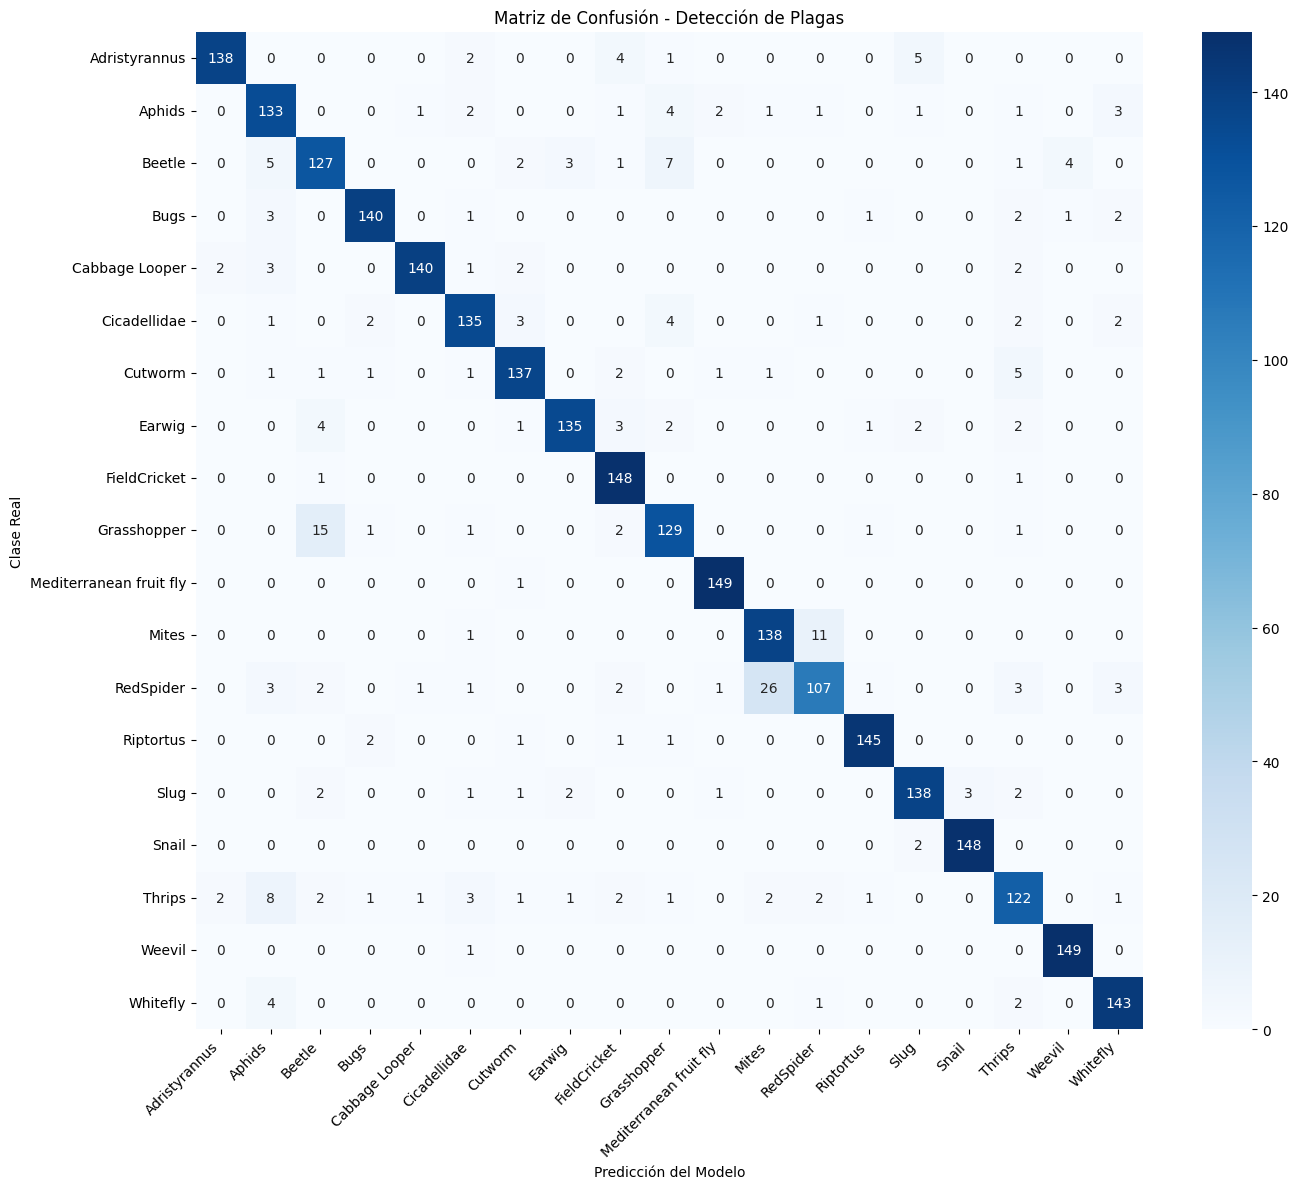


Reporte de Clasificación:
                         precision    recall  f1-score   support

          Adristyrannus       0.97      0.92      0.95       150
                 Aphids       0.83      0.89      0.86       150
                 Beetle       0.82      0.85      0.84       150
                   Bugs       0.95      0.93      0.94       150
         Cabbage Looper       0.98      0.93      0.96       150
           Cicadellidae       0.90      0.90      0.90       150
                Cutworm       0.92      0.91      0.92       150
                 Earwig       0.96      0.90      0.93       150
           FieldCricket       0.89      0.99      0.94       150
            Grasshopper       0.87      0.86      0.86       150
Mediterranean fruit fly       0.97      0.99      0.98       150
                  Mites       0.82      0.92      0.87       150
              RedSpider       0.87      0.71      0.78       150
              Riptortus       0.97      0.97      0.97       1

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch

# 1. Cargar los pesos del mejor modelo guardado durante la validación
modelo.load_state_dict(torch.load('mejor_modelo_plagas.pth'))
modelo.eval()

y_true = []
y_pred = []

print("Evaluando el modelo en el set de prueba...")

# 2. Inferencia sin cálculo de gradientes (ahorra memoria y tiempo)
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = modelo(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases)
plt.title('Matriz de Confusión - Detección de Plagas')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Generar el reporte de métricas detallado
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=clases, zero_division=0))

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, roc_auc_score

y_true = []
y_pred = []
y_probs = [] # Nuevo arreglo para las probabilidades

print("Evaluando el modelo y extrayendo probabilidades...")

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = modelo(inputs)

        # 1. Obtener probabilidades (Softmax) y predicciones (argmax)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy()) # Guardar probabilidades

# 2. Calcular Accuracy Global
accuracy_total = accuracy_score(y_true, y_pred)
print(f"Exactitud (Accuracy) Global: {accuracy_total * 100:.2f}%")

# 3. Calcular ROC-AUC para las 19 clases usando estrategia 'ovr' (One-vs-Rest)
# El 'macro' average calcula la métrica para cada clase y saca el promedio sin importar el desbalance
roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
print(f"ROC-AUC (Macro Average): {roc_auc:.4f}")

Evaluando el modelo y extrayendo probabilidades...
Exactitud (Accuracy) Global: 91.26%
ROC-AUC (Macro Average): 0.9968
